In [117]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [122]:
# functions

def half_mass_radius(radii, masses):
    idr = np.argsort(radii)
    r_sorted = radii[idr]
    m_sorted = masses[idr]    
    m_cum = np.cumsum(m_sorted)
    m_half = 0.5 * np.sum(masses)    
    i = np.searchsorted(m_cum, m_half)
    return r_sorted[i]

def radius(pos, centre):
    return np.sqrt((pos[:,0]-centre[0])**2 + (pos[:,1]-centre[1])**2 + (pos[:,2]-centre[2])**2)

def velocity(vel):
    return np.sqrt((vel[:,0])**2 + (vel[:,1])**2 + (vel[:,2])**2)

In [246]:
frame = '45'
g1 = h5py.File('GettingStarted/particles_snap_0'+frame+'_galID341536_Primary.hdf5', 'r')
if int(frame)<50:
    secondary = True
    g2 = h5py.File('GettingStarted/particles_snap_0'+frame+'_galID341536_Secondary.hdf5', 'r')
else:
    secondary = False
g1.keys()

<KeysViewHDF5 ['BlackHole', 'Gas', 'Header', 'Star']>

In [247]:
for name in g1['Header'].attrs.keys():
    print(name, '\t', g1['Header'].attrs[name])

Accretion_Units 	 Msun/yr
Masses_Units 	 Msun
Pos_Units 	 kpc (proper-physical)
Potential 	 (km/s)^2
Vel_Units 	 km/s


In [248]:
for name in g1['BlackHole'].keys():
    print(name, '\t', g1['BlackHole'][name][:])

BH_Density 	 [69304952.]
BH_Mass 	 [28602090.]
BH_Mdot 	 [0.02420432]
BH_MdotBondi 	 [0.02420398]
BH_MdotEddington 	 [0.31720668]
Mass 	 [28602090.]
ParticleIDs 	 [112186204367]
Position 	 [[ 5833.38711083 18191.76638961 21161.54825995]]
Potential 	 [-112169.44792614]
Velocity 	 [[-162.0223098   -50.90282728 -213.5158248 ]]


In [249]:
print('Stars:   ', g1['Star'].keys())
print('Gas:     ', g1['Gas'].keys())

Stars:    <KeysViewHDF5 ['Mass', 'MostBoundParticle', 'MostBoundParticleVel', 'ParticleID', 'Position', 'Potential', 'StarFormationTime', 'Velocity']>
Gas:      <KeysViewHDF5 ['Mass', 'ParticleID', 'Position', 'StarFormationRate', 'Velocity']>


In [250]:
# radii
r1s = radius(g1['Star']['Position'], g1['Star']['MostBoundParticle'])
r1g= radius(g1['Gas']['Position'], g1['Star']['MostBoundParticle'])

# velocities
v1s = velocity(g1['Star']['Velocity'])
v1g = velocity(g1['Gas']['Velocity'])

In [251]:
g1['Star']['Mass'][:]

array([59219.39 , 69491.81 , 70049.75 , ..., 70910.57 , 62455.055,
       51347.113], dtype=float32)

In [252]:
if secondary:
    # radii
    r2s = radius(g2['Star']['Position'], g2['Star']['MostBoundParticle'])
    r2g= radius(g2['Gas']['Position'], g2['Star']['MostBoundParticle'])
    
    # velocities
    v2s = velocity(g2['Star']['Velocity'])
    v2g = velocity(g2['Gas']['Velocity'])

### Mass, velocity and radius distributions for the 2 galaxies

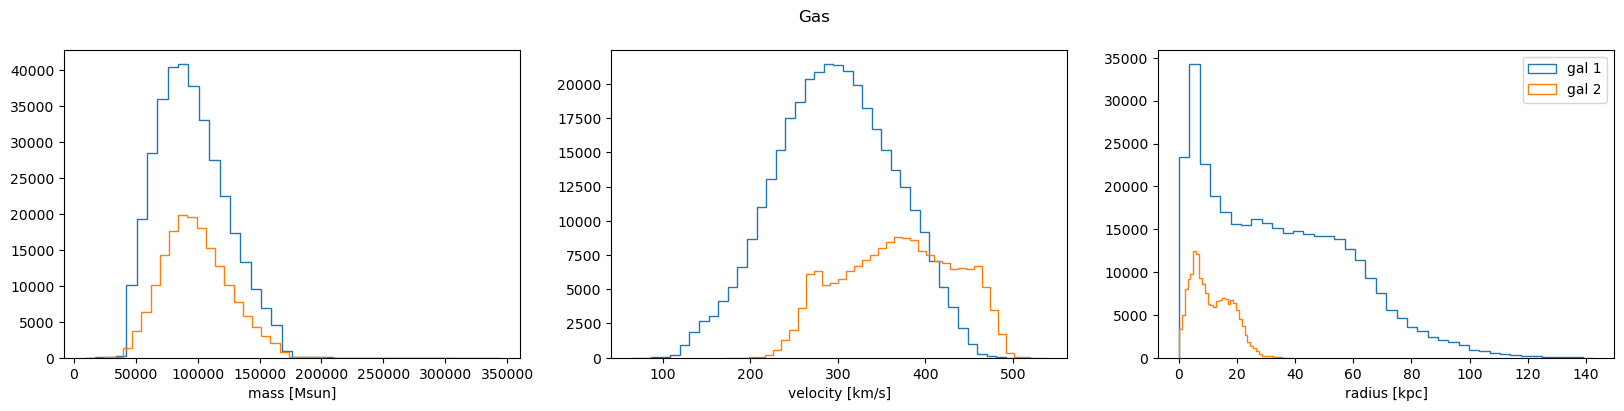

In [253]:
fig = plt.figure(figsize=(20,4))
fig.suptitle('Gas')

ax1 = fig.add_subplot(131)
ax1.hist(g1['Gas']['Mass'][:], 40, histtype='step', label='gal 1')
ax1.hist(g2['Gas']['Mass'][:], 40, histtype='step', label='gal 2')
plt.xlabel('mass [Msun]')

ax2 = fig.add_subplot(132)
ax2.hist(v1g, 40, histtype='step', label='gal 1')
ax2.hist(v2g, 40, histtype='step', label='gal 2')
plt.xlabel('velocity [km/s]')

ax3 = fig.add_subplot(133)
ax3.hist(r1g, 40, histtype='step', label='gal 1')
ax3.hist(r2g, 40, histtype='step', label='gal 2')
plt.xlabel('radius [kpc]')

plt.legend()
plt.show()

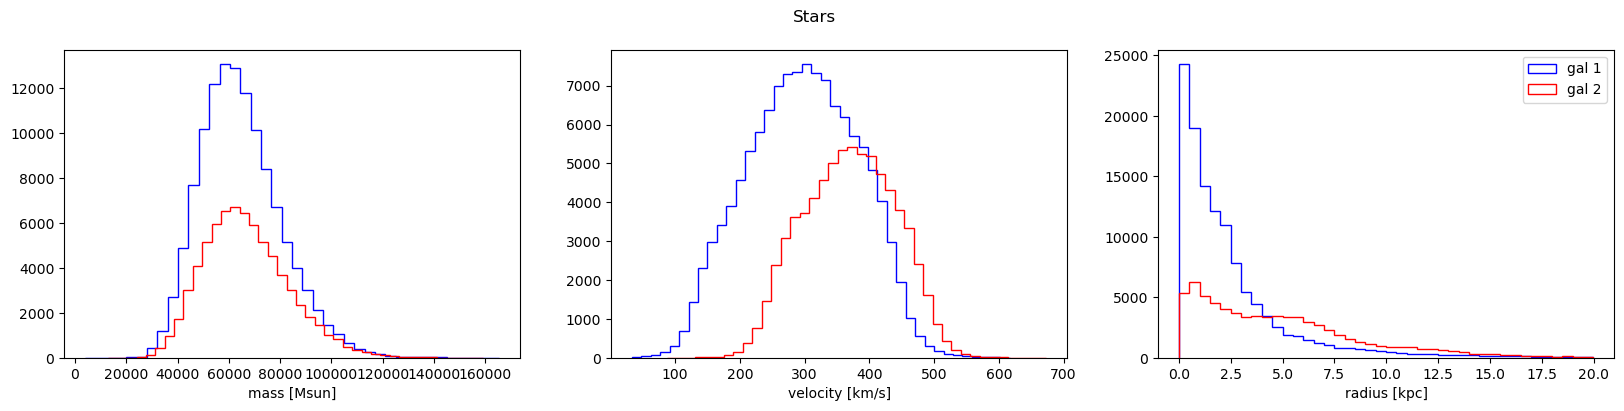

In [254]:
fig = plt.figure(figsize=(20,4))
fig.suptitle('Stars')

ax1 = fig.add_subplot(131)
ax1.hist(g1['Star']['Mass'][:], 40, histtype='step', color='b', label='gal 1')
ax1.hist(g2['Star']['Mass'][:], 40, histtype='step', color='r', label='gal 2')
plt.xlabel('mass [Msun]')

ax2 = fig.add_subplot(132)
ax2.hist(v1s, 40, histtype='step', color='b', label='gal 1')
ax2.hist(v2s, 40, histtype='step', color='r', label='gal 2')
plt.xlabel('velocity [km/s]')

ax3 = fig.add_subplot(133)
ax3.hist(r1s[r1s<20], 40, histtype='step', color='b', label='gal 1')
ax3.hist(r2s[r2s<20], 40, histtype='step', color='r', label='gal 2')
plt.xlabel('radius [kpc]')

plt.legend()
plt.show()

### Half-mass radius

In [300]:
# half-mass radius for galaxy 1

HMRs = half_mass_radius(r1s, g1['Star']['Mass'][:])
print('GALAXY 1\nStellar HMR =', HMRs, 'kpc')

HMRg = half_mass_radius(r1g, g1['Gas']['Mass'][:])
print('Gas HMR =', HMRg, 'kpc')

# half-mass radius for galaxy 2

HMRs2 = half_mass_radius(r2s, g2['Star']['Mass'][:])
print('\nGALAXY 2\nStellar HMR =', HMRs2, 'kpc')

HMRg2 = half_mass_radius(r2g, g2['Gas']['Mass'][:])
print('Gas HMR =', HMRg2, 'kpc')

GALAXY 1
Stellar HMR = 1.7188954095382172 kpc
Gas HMR = 30.376793341021042 kpc

GALAXY 2
Stellar HMR = 4.209286112592844 kpc
Gas HMR = 10.479930445278182 kpc


### Mass-radius relation

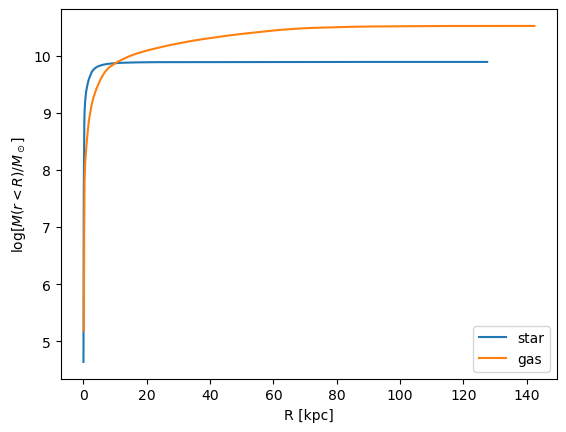

In [256]:
# mass-radius relation
idr = np.argsort(r1s)
r_sorted = r1s[idr]
m_sorted = g1['Star']['Mass'][:][idr]    
m_cum = np.cumsum(m_sorted)
plt.plot(r1s[idr], np.log10(m_cum), label='star')

idr = np.argsort(r1g)
r_sorted = r1g[idr]
m_sorted = g1['Gas']['Mass'][:][idr]    
m_cum = np.cumsum(m_sorted)
plt.plot(r1g[idr], np.log10(m_cum), label='gas')

plt.xlabel('R [kpc]')
plt.ylabel('log[$M(r<R)/M_\odot$]')
plt.legend()
plt.show()

### Radius-velocity relation

/home/sandokan/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sandokan/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


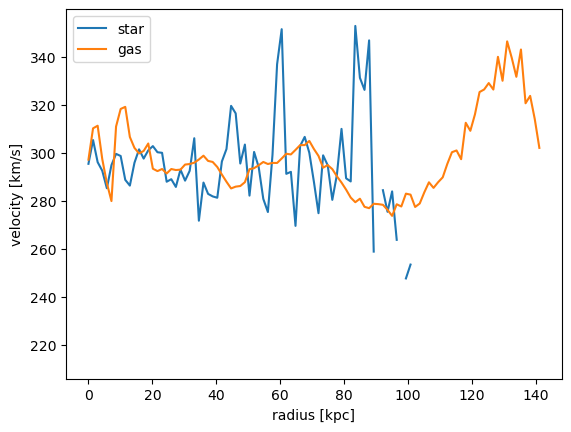

In [257]:
# radius-velocity relation
radii = np.linspace(0,max(r1g),100)
dr = radii[1]-radii[0]
Svel = []
Gvel = []

for r in radii:
    Svel.append( np.mean(v1s[(r1s>r)&(r1s<r+dr)]) )
    Gvel.append( np.mean(v1g[(r1g>r)&(r1g<r+dr)]) )

plt.plot(radii, Svel, label='star')
plt.plot(radii, Gvel, label='gas')
plt.xlabel('radius [kpc]')
plt.ylabel('velocity [km/s]')
plt.legend()
plt.show()

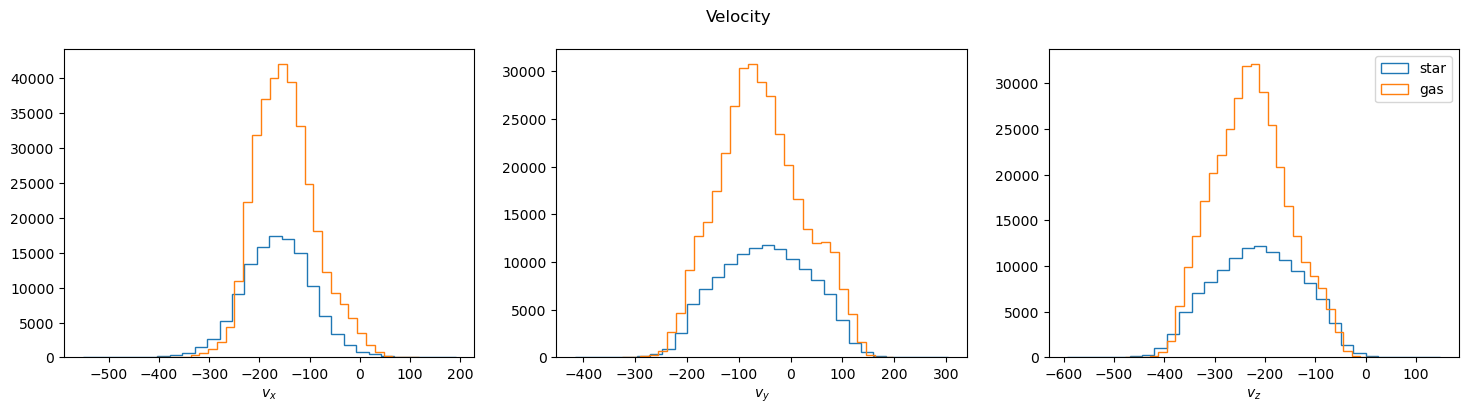

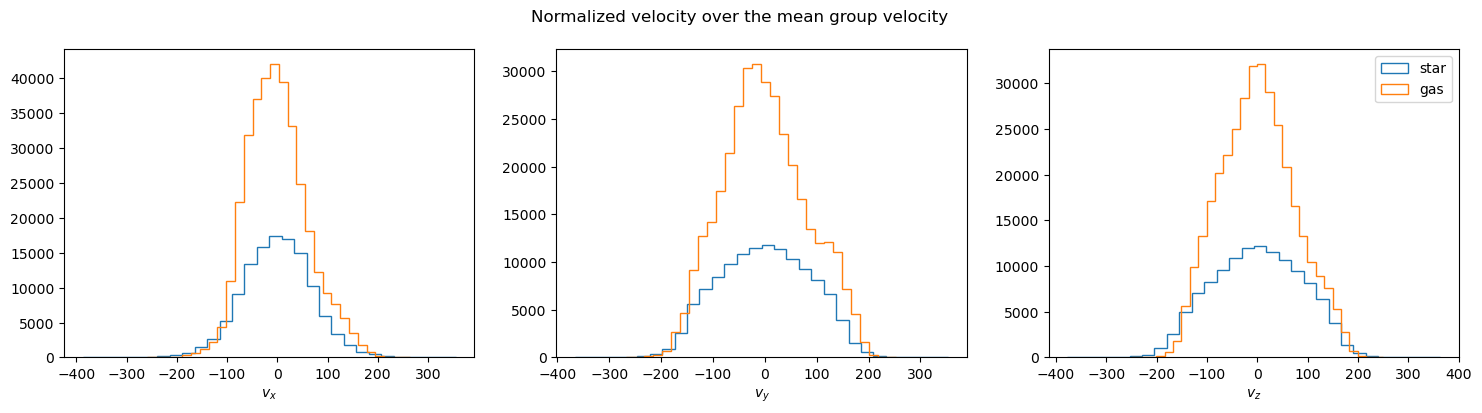

In [273]:
lab = ['$v_x$', '$v_y$', '$v_z$']

fig1 = plt.figure(figsize=(18,4))
fig1.suptitle('Velocity')
for i in range(3):
    ax = fig1.add_subplot(1,3,i+1)
    ax.hist(np.array(g1['Star']['Velocity'])[:,i], 30, histtype='step', label='star')
    ax.hist(np.array(g1['Gas']['Velocity'])[:,i], 30, histtype='step', label='gas')
    ax.set_xlabel(lab[i])
plt.legend()
plt.show()
#------------------------------------------------------------
s_pos = np.array(g1['Star']['Position'][:]).T
s_vel = np.array(g1['Star']['Velocity'][:]).T
g_pos = np.array(g1['Gas']['Position'][:]).T
g_vel = np.array(g1['Gas']['Velocity'][:]).T

s_vel_mean = [np.mean(s_vel[0]), np.mean(s_vel[1]), np.mean(s_vel[2])]
g_vel_mean = [np.mean(g_vel[0]), np.mean(g_vel[1]), np.mean(g_vel[2])]
sv = []
gv = []
for i in range(3):
    sv.append(s_vel[i] - s_vel_mean[i])
    gv.append(g_vel[i] - g_vel_mean[i])
sv = np.array(sv)
gv = np.array(gv)

#--------------------------------------------------------------
fig2 = plt.figure(figsize=(18,4))
fig2.suptitle('Normalized velocity over the mean group velocity')
for i in range(3):
    ax = fig2.add_subplot(1,3,i+1)
    ax.hist(sv[i], 30, histtype='step', label='star')
    ax.hist(gv[i], 30, histtype='step', label='gas')
    ax.set_xlabel(lab[i])
plt.legend()
plt.show()

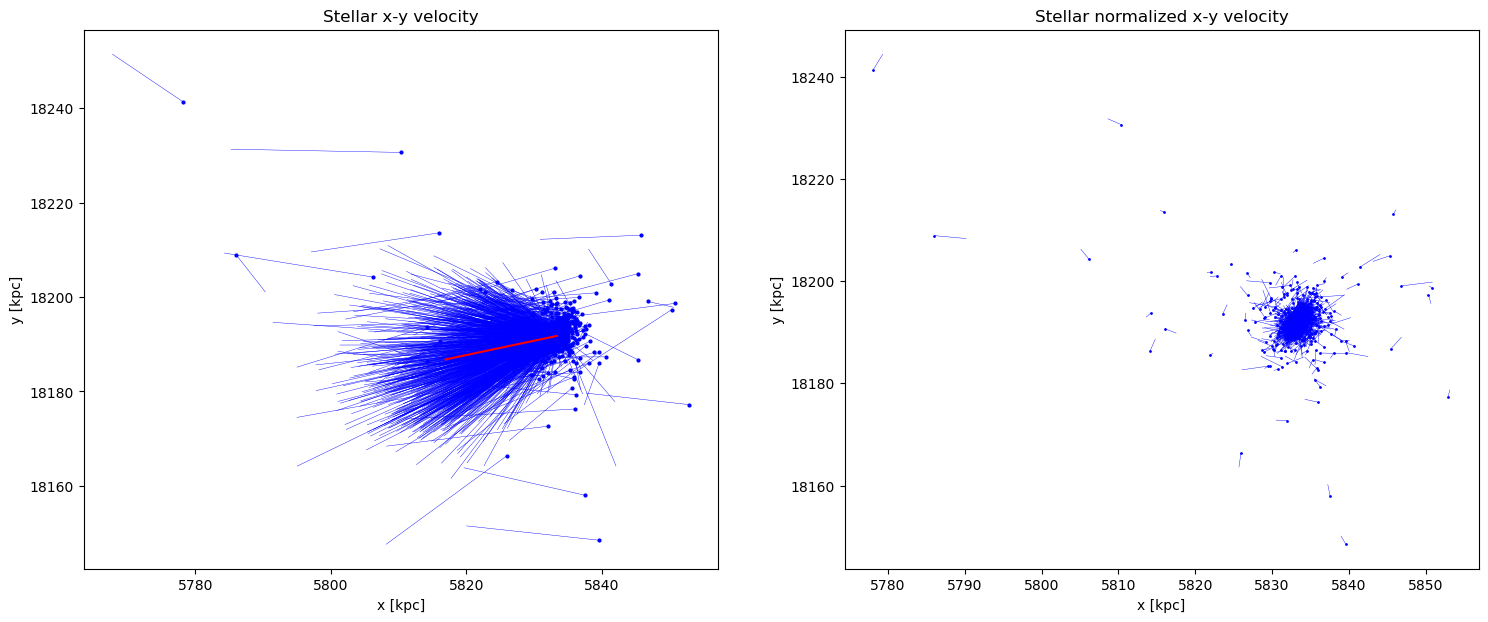

In [275]:
ds = 100

fig = plt.figure(figsize=(18,7))
ax = fig.add_subplot(121)
plt.plot([s_pos[0,::ds], s_pos[0,::ds]+s_vel[0,::ds]/10], [s_pos[1,::ds], s_pos[1,::ds]+s_vel[1,::ds]/10], c='b', lw=0.3)
plt.plot(s_pos[0,::ds], s_pos[1,::ds], 'o', markersize=2, c='b')
plt.plot([g1['Star']['MostBoundParticle'][0], g1['Star']['MostBoundParticle'][0]+s_vel_mean[0]/10], [g1['Star']['MostBoundParticle'][1], g1['Star']['MostBoundParticle'][1]+s_vel_mean[1]/10], c='r')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title('Stellar x-y velocity')

ax = fig.add_subplot(122)
plt.plot([s_pos[0,::ds], s_pos[0,::ds]+sv[0,::ds]/50], [s_pos[1,::ds], s_pos[1,::ds]+sv[1,::ds]/50], c='b', lw=0.3)
plt.plot(s_pos[0,::ds], s_pos[1,::ds], 'o', markersize=1, c='b')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title('Stellar normalized x-y velocity')

plt.show()

In [294]:
################ stars #####################

vv = np.sqrt(sv[0]**2+sv[1]**2+sv[2]**2)

r_sort = np.sort(r1s)
irs = np.argsort(r1s)
vv_sort = vv[irs]

# average 
N = 500
v_av = np.zeros(len(vv_sort)-2*N)
for i in range(len(v_av)):
    v_av[i] = np.mean(vv_sort[i-N:i+N])

################## gas #####################

vvg = np.sqrt(gv[0]**2+gv[1]**2+gv[2]**2)

rg_sort = np.sort(r1g)
irs_g = np.argsort(r1g)
vvg_sort = vvg[irs_g]

# average 
vg_av = np.zeros(len(vvg_sort)-2*N)
for i in range(len(vg_av)):
    vg_av[i] = np.mean(vvg_sort[i-N:i+N])

/home/sandokan/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sandokan/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


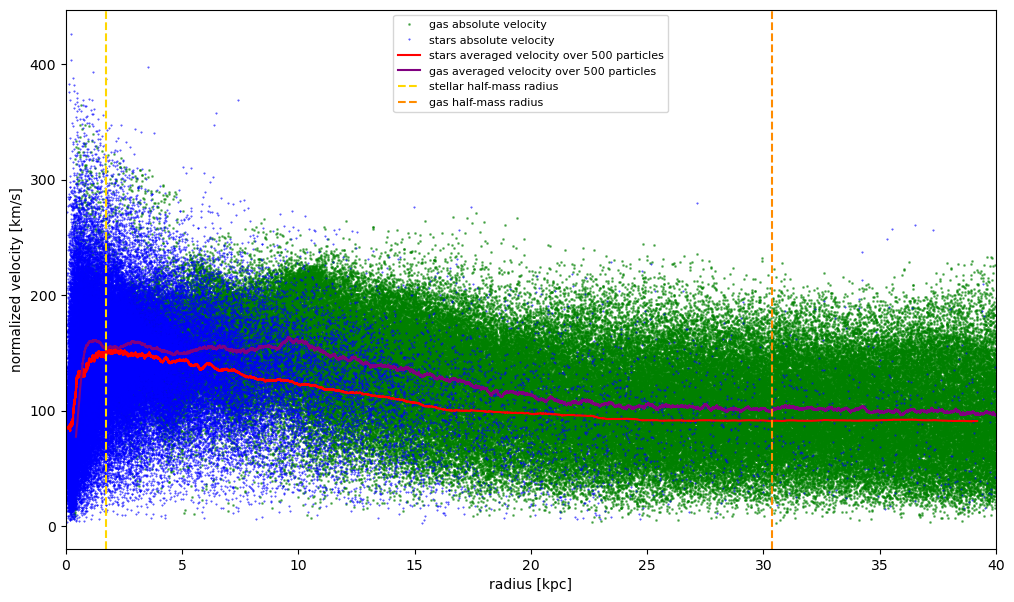

In [295]:
plt.figure(figsize=(12,7))
plt.plot(rg_sort, vvg_sort, 'o', markersize=1, color='g', alpha=0.5, label='gas absolute velocity')
plt.plot(r_sort, vv_sort, '*', markersize=1, color='b', alpha=0.5, label='stars absolute velocity')

plt.plot(r_sort[N:-N], v_av, c='r', label='stars averaged velocity over '+str(N)+' particles')
plt.plot(rg_sort[N:-N], vg_av, c='purple', label='gas averaged velocity over '+str(N)+' particles')

plt.axvline(HMRs, color='gold', ls='dashed', label='stellar half-mass radius')
plt.axvline(HMRg, color='darkorange', ls='dashed', label='gas half-mass radius')

plt.xlim(0,40)
plt.xlabel('radius [kpc]')
plt.ylabel('normalized velocity [km/s]')
plt.legend(fontsize=8)
plt.show()

### Star formation rate

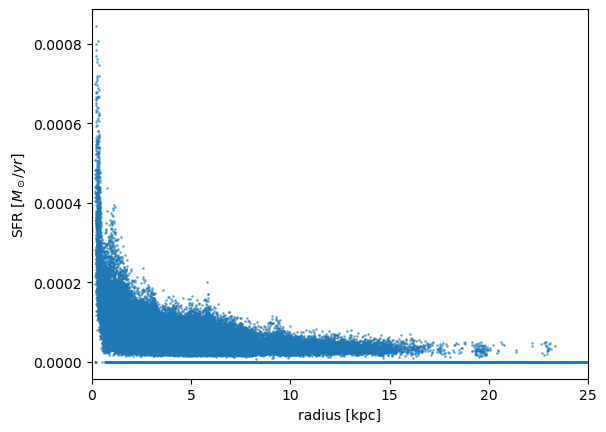

In [95]:
plt.scatter(r1g, g1['Gas']['StarFormationRate'][:], s=1, alpha=0.5)
plt.xlim(0,25)
#plt.ylim(0,plt.ylim()[1])
plt.xlabel('radius [kpc]')
plt.ylabel('SFR [$M_\odot/yr$]')
plt.show()

## 2D pictures

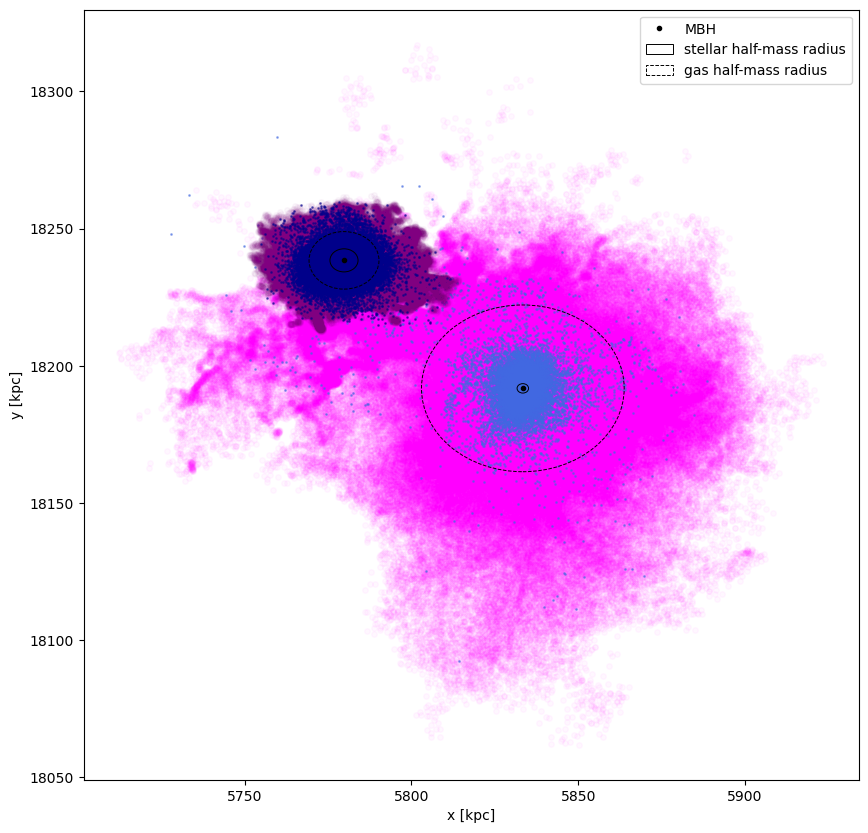

In [302]:
#secondary = True
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10,10))
x_axis = 0
y_axis = 1
# Primary
plt.plot(g1['Gas']['Position'][:,x_axis], g1['Gas']['Position'][:,y_axis], 'o', color='magenta', markersize=4, alpha=0.03)
plt.plot(g1['Star']['Position'][:,x_axis], g1['Star']['Position'][:,y_axis], 'o', color='royalblue', markersize=1, alpha=0.5)
plt.plot(g1['BlackHole']['Position'][:,x_axis], g1['BlackHole']['Position'][:,y_axis], 'o', color='k', markersize=3, label='MBH')

Cstar = Circle((g1['BlackHole']['Position'][:,x_axis], g1['BlackHole']['Position'][:,y_axis]), radius=HMRs, fill=False, color='k', linewidth=0.7, zorder=2, label='stellar half-mass radius')
Cgas = Circle((g1['BlackHole']['Position'][:,x_axis], g1['BlackHole']['Position'][:,y_axis]), radius=HMRg, fill=False, color='k', ls='dashed', linewidth=0.7, zorder=2, label='gas half-mass radius')
ax.add_patch(Cstar)
ax.add_patch(Cgas)

# Secondary
if secondary:
    plt.plot(g2['Gas']['Position'][:,x_axis], g2['Gas']['Position'][:,y_axis], 'o', color='purple', markersize=4, alpha=0.03)
    plt.plot(g2['Star']['Position'][:,x_axis], g2['Star']['Position'][:,y_axis], 'o', color='darkblue', markersize=1, alpha=0.5)
    plt.plot(g2['BlackHole']['Position'][:,x_axis], g2['BlackHole']['Position'][:,y_axis], 'o', color='k', markersize=3)

    Cstar = Circle((g2['BlackHole']['Position'][:,x_axis], g2['BlackHole']['Position'][:,y_axis]), radius=HMRs2, fill=False, color='k', linewidth=0.7, zorder=2)
    Cgas = Circle((g2['BlackHole']['Position'][:,x_axis], g2['BlackHole']['Position'][:,y_axis]), radius=HMRg2, fill=False, color='k', ls='dashed', linewidth=0.7, zorder=2)
    ax.add_patch(Cstar)
    ax.add_patch(Cgas)

plt.legend()
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.show()

### Super cool picture!!

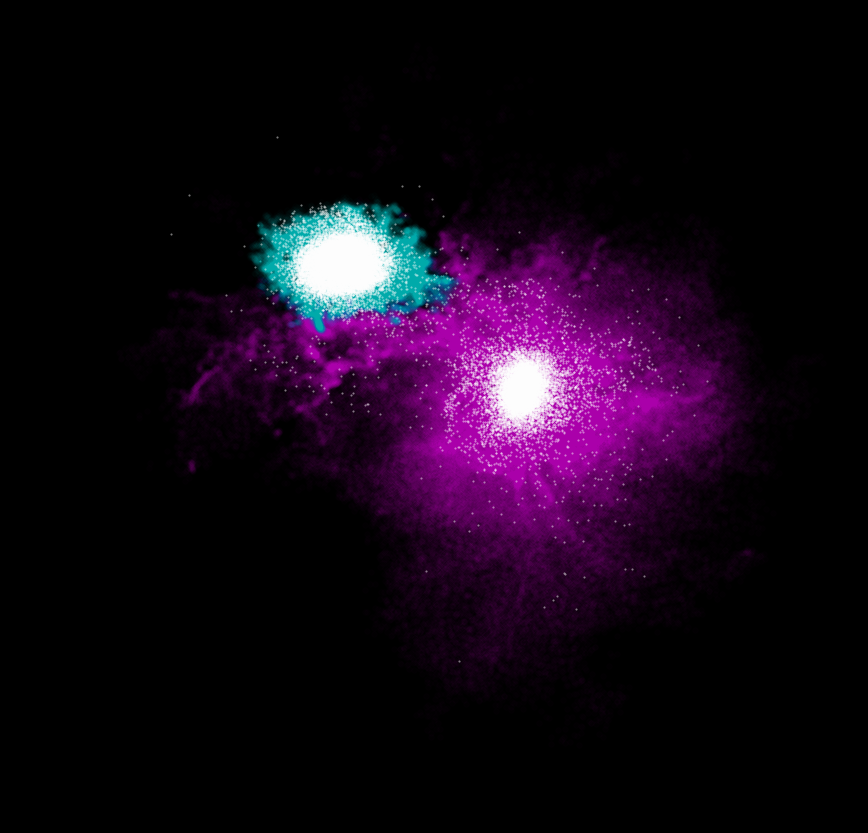

In [303]:
#secondary = True
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10,10))
x_axis = 0
y_axis = 1
# Primary
plt.plot(g1['Gas']['Position'][:,x_axis], g1['Gas']['Position'][:,y_axis], 'o', color='magenta', markersize=4, alpha=0.01)
plt.plot(g1['Star']['Position'][:,x_axis], g1['Star']['Position'][:,y_axis], 'o', color='w', markersize=0.5, alpha=0.5)
#plt.plot(g1['BlackHole']['Position'][:,x_axis], g1['BlackHole']['Position'][:,y_axis], 'o', color='k', markersize=3)

#Cstar = Circle((g1['BlackHole']['Position'][:,x_axis], g1['BlackHole']['Position'][:,y_axis]), radius=HMRs, fill=False, color='k', linewidth=1, zorder=2)
#Cgas = Circle((g1['BlackHole']['Position'][:,x_axis], g1['BlackHole']['Position'][:,y_axis]), radius=HMRg, fill=False, color='k', ls='dashed', linewidth=1, zorder=2)
#ax.add_patch(Cstar)
#ax.add_patch(Cgas)
fig.patch.set_facecolor('k') 
ax.set_facecolor('k') 

# Secondary
if secondary:
    plt.plot(g2['Gas']['Position'][:,x_axis], g2['Gas']['Position'][:,y_axis], 'o', color='aqua', markersize=4, alpha=0.01)
    plt.plot(g2['Star']['Position'][:,x_axis], g2['Star']['Position'][:,y_axis], 'o', color='w', markersize=0.5, alpha=0.5)
    #plt.plot(g2['BlackHole']['Position'][:,x_axis], g2['BlackHole']['Position'][:,y_axis], 'o', color='k', markersize=3)

plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.show()

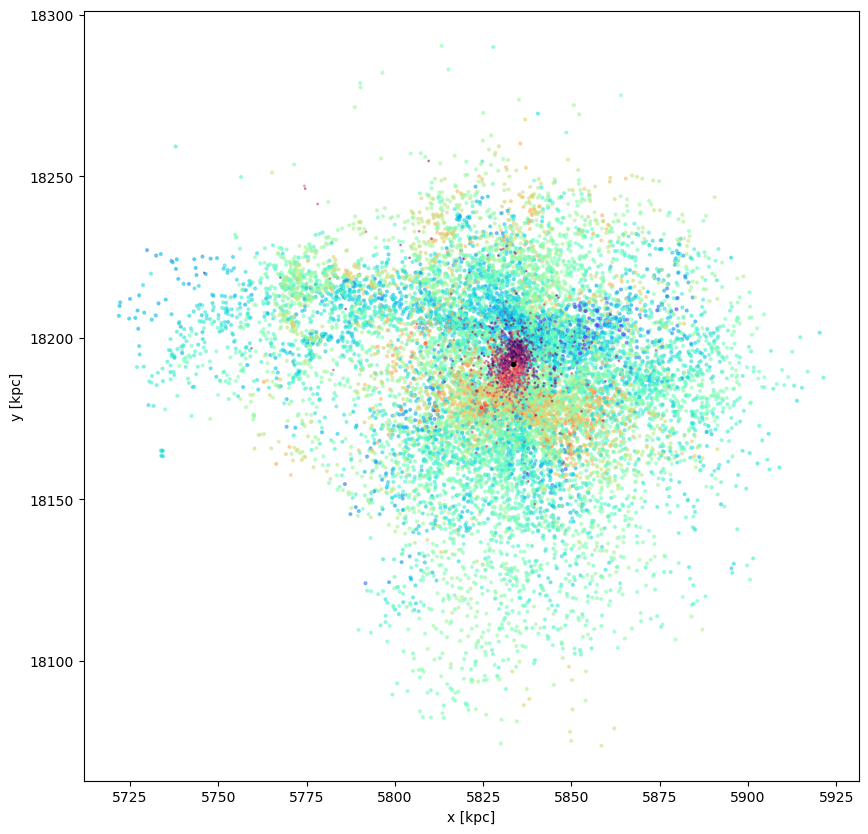

In [304]:
# velocity
plt.figure(figsize=(10,10))
x_axis = 0
y_axis = 1
n = 20   # downsampling
# Primary
plt.scatter(g1['Gas']['Position'][::n,x_axis], g1['Gas']['Position'][::n,y_axis], c=v1g[::n], cmap='rainbow', s=4, alpha=0.5)
plt.scatter(g1['Star']['Position'][::n,x_axis], g1['Star']['Position'][::n,y_axis], c=v1s[::n], cmap='magma', s=1, alpha=0.5)
plt.plot(g1['BlackHole']['Position'][::n,x_axis], g1['BlackHole']['Position'][::n,y_axis], 'o', color='k', markersize=3)

#plt.xlim(5745,5755)
#plt.ylim(17870,17880)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.show()

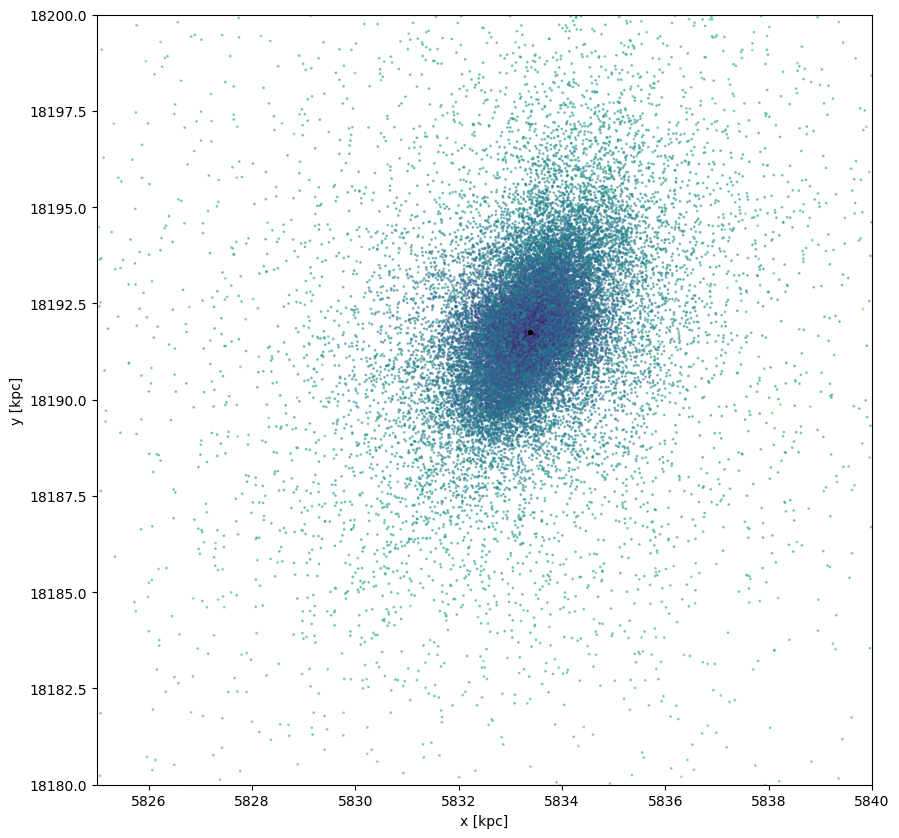

In [305]:
# Star formation rate
plt.figure(figsize=(10,10))
x_axis = 0
y_axis = 1
n = 3   # downsampling
# Primary
#plt.scatter(g1['Gas']['Position'][::n,x_axis], g1['Gas']['Position'][::n,y_axis], c=g1['Gas']['StarFormationRate'][::n], cmap='viridis', s=2, alpha=0.5)
plt.scatter(g1['Star']['Position'][::n,x_axis], g1['Star']['Position'][::n,y_axis], c=g1['Star']['Potential'][::n], cmap='viridis', s=1, alpha=0.5)
plt.plot(g1['BlackHole']['Position'][::n,x_axis], g1['BlackHole']['Position'][::n,y_axis], 'o', color='k', markersize=3)

plt.xlim(5825,5840)
plt.ylim(18180,18200)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.show()